In [15]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [16]:
# Load the data
users = pd.read_csv('data/userbase.csv')
sent = pd.read_csv('data/sent_emails.csv')
responded = pd.read_csv('data/responded.csv')

print("Userbase shape:", users.shape)
print("Sent emails shape:", sent.shape)
print("Responded shape:", responded.shape)

Userbase shape: (500000, 6)
Sent emails shape: (2476354, 3)
Responded shape: (378208, 3)


In [17]:
#Explore the Data
print("=== USERBASE ===")
print(users.head())
print()
print(users.info())
print()

print("=== SENT EMAILS ===")
print(sent.head())
print()

print("=== RESPONDED ===")
print(responded.head())

=== USERBASE ===
   Customer_ID Gender Type                Email_Address  Age  Tenure
0            1      M    C                  Mph@msn.com   38      12
1            2      F    B  SophcYN7381qMe8lRqK@aol.com   37      23
2            3      F    C                   xE@msn.com   32      15
3            4      M    C          WduR0o0@comcast.net   31      24
4            5      M    C     walHI9cmWJIBKvy0@aol.com   35      13

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Customer_ID    500000 non-null  int64 
 1   Gender         500000 non-null  object
 2   Type           500000 non-null  object
 3   Email_Address  500000 non-null  object
 4   Age            500000 non-null  int64 
 5   Tenure         500000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 22.9+ MB
None

=== SENT EMAILS ===
    Sent_Date  Customer_ID  S

In [18]:
#Calculate Open Rates

#count how many emails were sent per subject line
sent_counts = sent.groupby('SubjectLine_ID').size().reset_index(name='emails_sent')

#count how many responses per subject line
responded_counts = responded.groupby('SubjectLine_ID').size().reset_index(name='emails_responded')

#merge the two together
summary = sent_counts.merge(responded_counts, on='SubjectLine_ID')

#calculate open rate as a percentage
summary['open_rate'] = (summary['emails_responded'] / summary['emails_sent']) * 100

print(summary)

   SubjectLine_ID  emails_sent  emails_responded  open_rate
0               1       826717            131335  15.886331
1               2       824837            130383  15.807123
2               3       824800            116490  14.123424


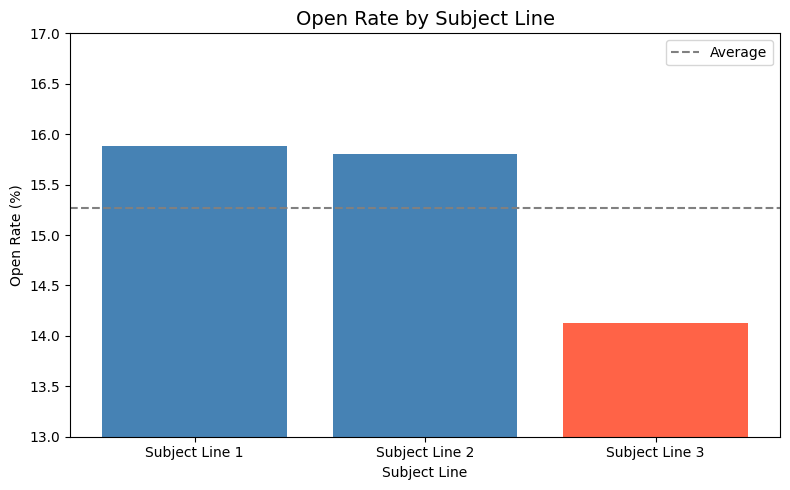

In [19]:
#Visualize Open Rates
plt.figure(figsize=(8, 5))
plt.bar(['Subject Line 1', 'Subject Line 2', 'Subject Line 3'],
        summary['open_rate'],
        color=['steelblue', 'steelblue', 'tomato'])

plt.title('Open Rate by Subject Line', fontsize=14)
plt.xlabel('Subject Line')
plt.ylabel('Open Rate (%)')
plt.ylim(13, 17)
plt.axhline(y=summary['open_rate'].mean(), color='gray', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Chi-Square Test
from scipy.stats import chi2_contingency

# Build a contingency table
# Rows = subject lines, Columns = [responded, did not respond]
contingency_table = summary[['emails_responded']].copy()
contingency_table['not_responded'] = summary['emails_sent'] - summary['emails_responded']

print("Contingency Table:")
print(contingency_table.values)

# Run the chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table.values)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.10f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("\n Result is statistically significant: the differences are real, not random chance")
else:
    print("\n Result is NOT statistically significant: differences could be due to chance.")

Contingency Table:
[[131335 695382]
 [130383 694454]
 [116490 708310]]

Chi-square statistic: 1264.51
P-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
Degrees of freedom: 2

 Result is statistically significant: the differences are real, not random chance!


In [21]:
#Conclusion & Recommendation
print("""

A/B/C TEST 


OBJECTIVE:
Test which of 3 email subject lines drives the highest open rate.

RESULTS:
  Subject Line 1: 15.89% open rate (826,717 sent)
  Subject Line 2: 15.81% open rate (824,837 sent)
  Subject Line 3: 14.12% open rate (824,800 sent)

STATISTICAL TEST:
  Chi-square statistic : 1264.51
  P-value              : ~0.0000 (< 0.05 threshold)
  Conclusion           : Differences are statistically significant

RECOMMENDATION:
  1. Roll out Subject Line 1 as the primary subject line
  2. Retire Subject Line 3 — it underperforms by ~1.7 percentage points
  3. Subject Lines 1 and 2 are close, but Subject Line 1 edges ahead

IMPACT:
  If all 2,476,354 emails had used Subject Line 1 instead of Subject Line 3,
  an estimated extra responses could have been generated.
""")

# Calculate the business impact number
extra_responses = ((summary.loc[0, 'open_rate'] - summary.loc[2, 'open_rate']) / 100) * summary.loc[2, 'emails_sent']
print(f"  Estimated extra responses from switching SL3 → SL1: {int(extra_responses):,}")



A/B/C TEST 


OBJECTIVE:
Test which of 3 email subject lines drives the highest open rate.

RESULTS:
  Subject Line 1: 15.89% open rate (826,717 sent)
  Subject Line 2: 15.81% open rate (824,837 sent)
  Subject Line 3: 14.12% open rate (824,800 sent)

STATISTICAL TEST:
  Chi-square statistic : 1264.51
  P-value              : ~0.0000 (< 0.05 threshold)
  Conclusion           : Differences are statistically significant

RECOMMENDATION:
  1. Roll out Subject Line 1 as the primary subject line
  2. Retire Subject Line 3 — it underperforms by ~1.7 percentage points
  3. Subject Lines 1 and 2 are close, but Subject Line 1 edges ahead

IMPACT:
  If all 2,476,354 emails had used Subject Line 1 instead of Subject Line 3,
  an estimated extra responses could have been generated.

  Estimated extra responses from switching SL3 → SL1: 14,540


In [29]:
#Merge Userbase for Segmented Analysis

# Merge sent emails with userbase to get customer info
sent_with_users = sent.merge(users[['Customer_ID', 'Gender', 'Type', 'Age']])

# Merge responded with userbase too
responded_with_users = responded.merge(users[['Customer_ID', 'Gender', 'Type', 'Age']])

print("Sent with users shape:", sent_with_users.shape)
print("Responded with users shape:", responded_with_users.shape)
print()
print(sent_with_users.head())

Sent with users shape: (2476354, 6)
Responded with users shape: (378208, 6)

    Sent_Date  Customer_ID  SubjectLine_ID Gender Type  Age
0  2016-01-28         1413               2      M    B   44
1  2016-03-02        83889               2      M    C   29
2  2016-03-09       457832               3      M    C   26
3  2016-01-20       127772               1      M    C   26
4  2016-02-03       192123               3      M    C   33


In [34]:
#Category Analysis

def get_open_rates(segment_col):
    # Count sent per subject line per segment
    seg_sent = sent_with_users.groupby(['SubjectLine_ID', segment_col]).size().reset_index(name='sent')
    
    # Count responded per subject line per segment
    seg_responded = responded_with_users.groupby(['SubjectLine_ID', segment_col]).size().reset_index(name='responded')
    
    # Merge and calculate open rate
    seg = seg_sent.merge(seg_responded, on=['SubjectLine_ID', segment_col])
    seg['open_rate'] = (seg['responded'] / seg['sent']) * 100
    
    return seg

# Run for Gender and Type
gender_analysis = get_open_rates('Gender')
type_analysis = get_open_rates('Type')

print("=== BY GENDER ===")
print(gender_analysis.to_string(index=False))
print()
print("=== BY TYPE (B: Business, C: Consumer) ===")
print(type_analysis.to_string(index=False))

=== BY GENDER ===
 SubjectLine_ID Gender   sent  responded  open_rate
              1      F 288709      48932  16.948554
              1      M 538008      82403  15.316315
              2      F 289070      48987  16.946414
              2      M 535767      81396  15.192425
              3      F 288650      44269  15.336567
              3      M 536150      72221  13.470297

=== BY TYPE (B: Business, C: Consumer) ===
 SubjectLine_ID Type   sent  responded  open_rate
              1    B 165632      29037  17.531033
              1    C 661085     102298  15.474258
              2    B 164597      28483  17.304690
              2    C 660240     101900  15.433782
              3    B 164476      25752  15.656996
              3    C 660324      90738  13.741436


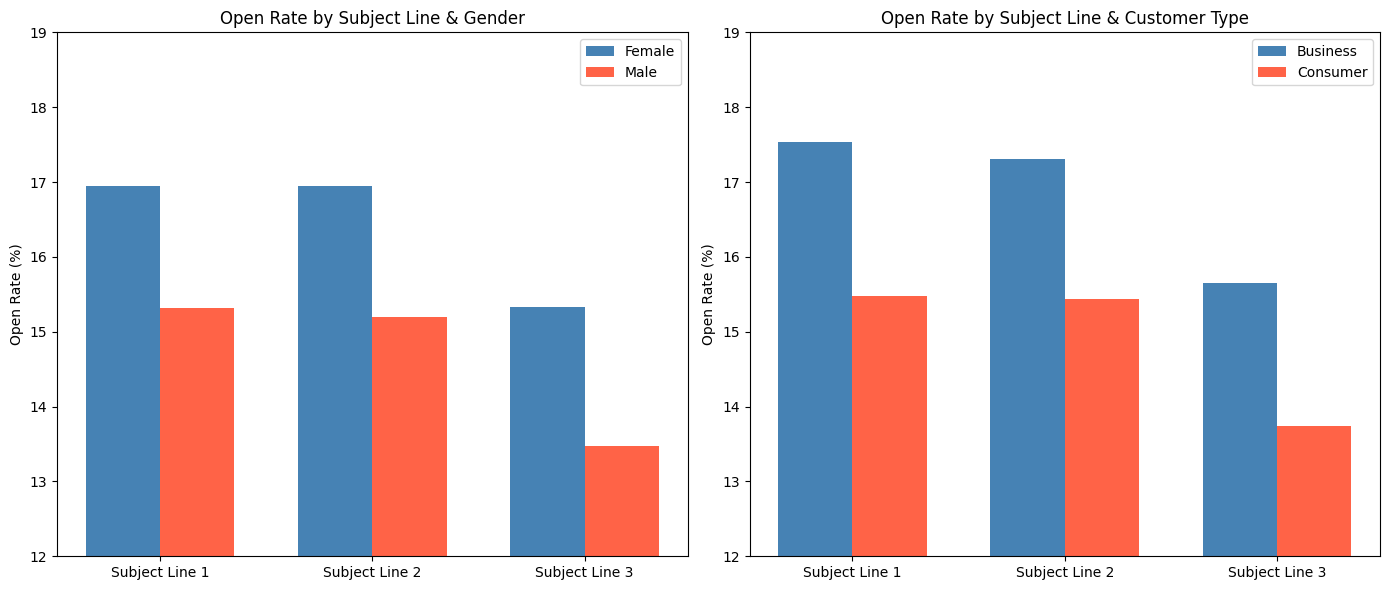

In [35]:
#Visualize Categories
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gender Plot ---
females = gender_analysis[gender_analysis['Gender'] == 'F']['open_rate'].values
males = gender_analysis[gender_analysis['Gender'] == 'M']['open_rate'].values
x = range(3)
width = 0.35

axes[0].bar([i - width/2 for i in x], females, width, label='Female', color='steelblue')
axes[0].bar([i + width/2 for i in x], males, width, label='Male', color='tomato')
axes[0].set_title('Open Rate by Subject Line & Gender')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Subject Line 1', 'Subject Line 2', 'Subject Line 3'])
axes[0].set_ylabel('Open Rate (%)')
axes[0].set_ylim(12, 19)
axes[0].legend()

# --- Type Plot ---
business = type_analysis[type_analysis['Type'] == 'B']['open_rate'].values
consumer = type_analysis[type_analysis['Type'] == 'C']['open_rate'].values

axes[1].bar([i - width/2 for i in x], business, width, label='Business', color='steelblue')
axes[1].bar([i + width/2 for i in x], consumer, width, label='Consumer', color='tomato')
axes[1].set_title('Open Rate by Subject Line & Customer Type')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Subject Line 1', 'Subject Line 2', 'Subject Line 3'])
axes[1].set_ylabel('Open Rate (%)')
axes[1].set_ylim(12, 19)
axes[1].legend()

plt.tight_layout()
plt.show()